In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))


In [29]:
df = pd.read_csv("../synthetic_waste_data.csv")

df.head(10)


,date,arrival_time,company,truck_id,waste_type,quantity_tons,quality_score,moisture_content,contamination_level,heating_value_MJ_per_kg
0,2022-01-01,2022-01-01 06:27:00,RegionalWaste Management,Reg3,Municipal,11.486050,7.929559,37.493209,2.070441,7.263229
1,2022-01-01,2022-01-01 06:32:00,RegionalWaste Management,Reg1,Industrial,19.855091,6.868888,18.746604,3.131112,11.807504
2,2022-01-01,2022-01-01 09:58:00,GreenWaste Solutions,Gre2,Organic,3.835948,6.364174,74.986417,3.635826,2.539645
3,2022-01-01,2022-01-01 10:06:00,IndustrialProcess Ltd,Ind1,Industrial,41.565434,8.821311,18.746604,1.178689,12.570800
4,2022-01-01,2022-01-01 10:14:00,GreenWaste Solutions,Gre1,Municipal,4.895075,6.149050,37.493209,3.850950,6.849568
5,2022-01-01,2022-01-01 10:58:00,IndustrialProcess Ltd,Ind2,Industrial,39.410074,8.032380,18.746604,1.967620,12.262369
6,2022-01-01,2022-01-01 14:33:00,BuildRight Construction,Bui1,Construction,12.316680,5.296440,22.495925,4.703560,5.789136
7,2022-01-01,2022-01-01 14:57:00,RegionalWaste Management,Reg2,Commercial,20.487152,5.962900,24.995472,4.037100,8.701316
8,2022-01-02,2022-01-02 07:09:00,IndustrialProcess Ltd,Ind1,Industrial,29.373903,9.197727,18.339785,0.802273,12.759647
9,2022-01-02,2022-01-02 09:22:00,CommercialServices Inc,Com4,Commercial,15.368228,6.675287,24.453047,3.324713,8.953922


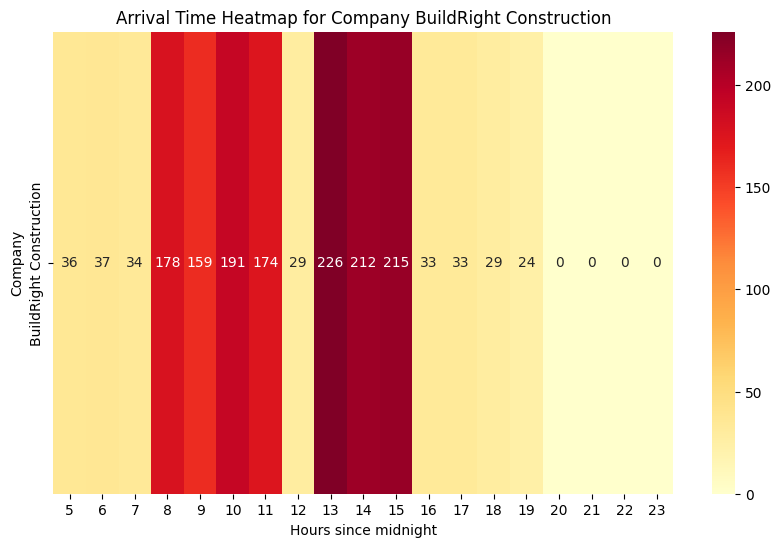

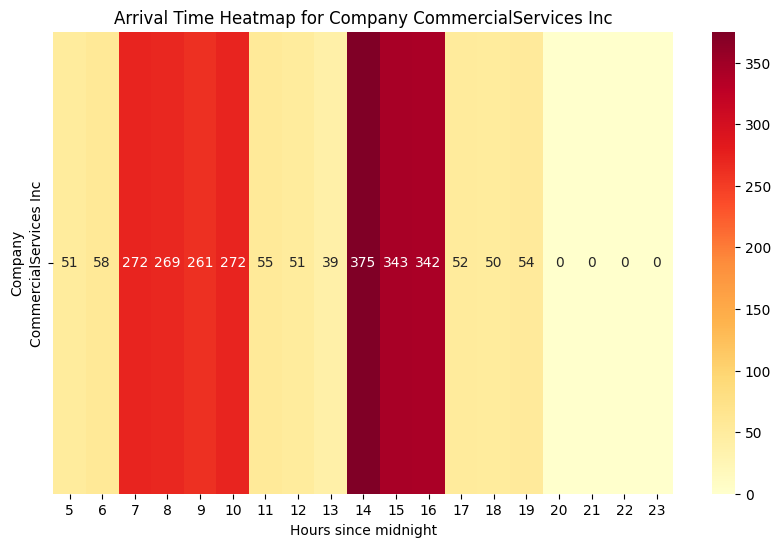

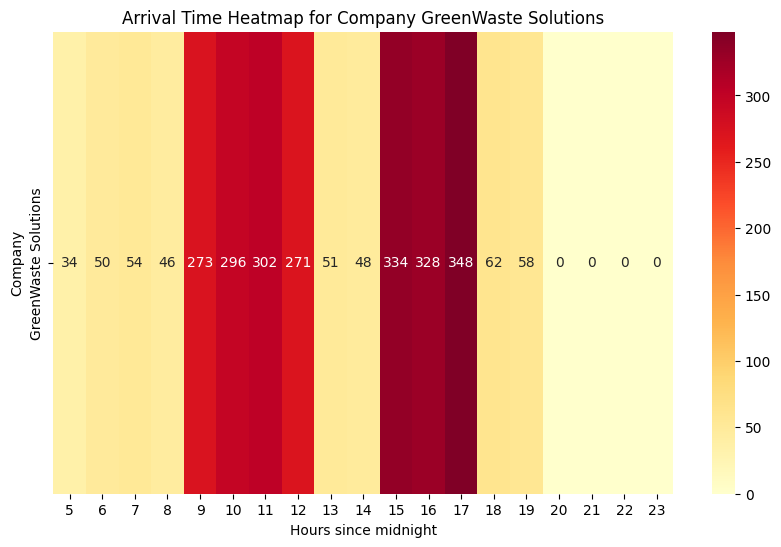

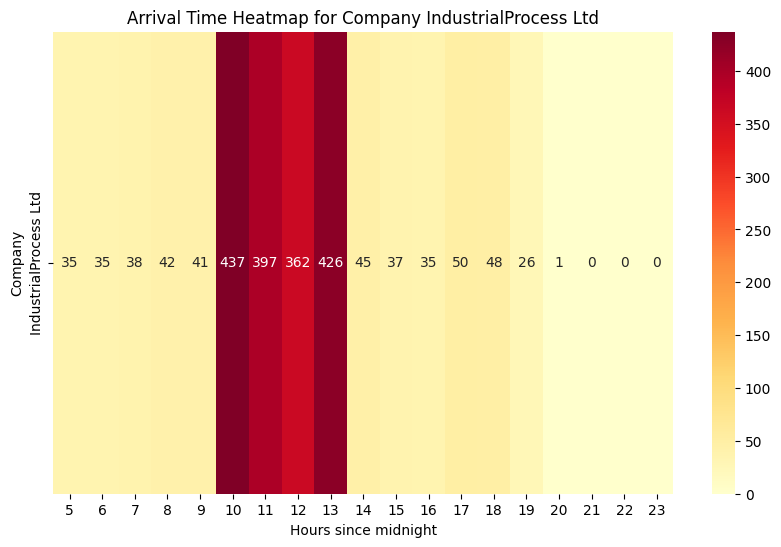

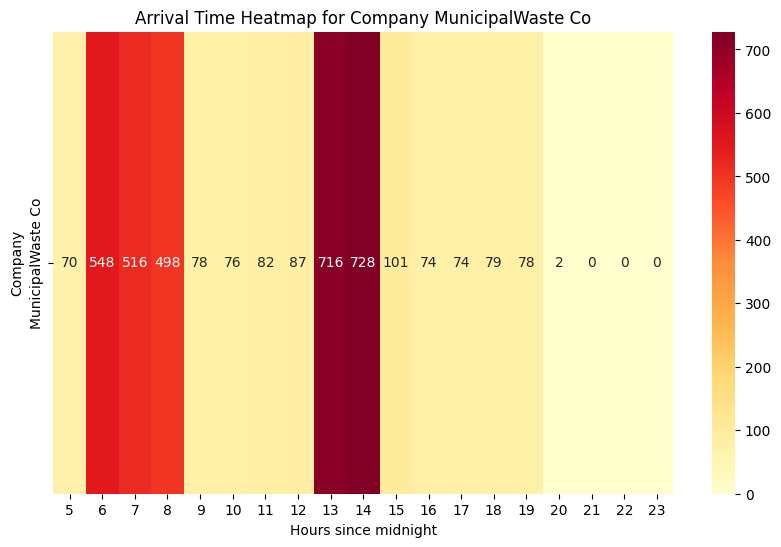

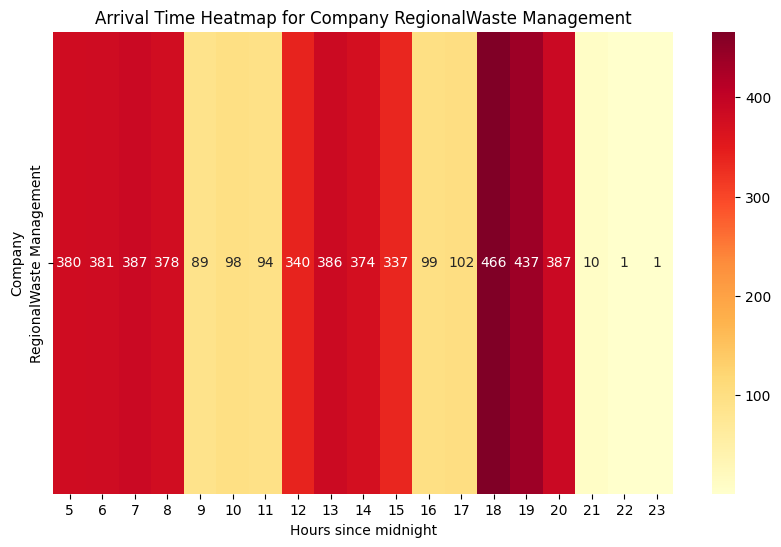

In [ ]:
df["arrival_time"] = pd.to_datetime(df["arrival_time"])
df['hours'] = df["arrival_time"].dt.hour


heatmap_data = df.groupby(['company', 'hours']).size().unstack(fill_value=0)

for company in heatmap_data.index:
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data.loc[company].to_frame().T, cmap='YlOrRd', annot=True, fmt='d')
    plt.title(f'Arrival Time Heatmap for Company {company}')
    plt.xlabel('Hours since midnight')
    plt.ylabel('Company')
    plt.show()